**Installing Fred API**

In [2]:
!pip install fredapi

**Importing Libraries**

In [3]:
from fredapi import Fred
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error,r2_score,f1_score,accuracy_score,mean_absolute_percentage_error

**Fred Api Key**

In [ ]:

fred = Fred(api_key="FRED_API_KEY")


**Extracting Macroeconomic data from Freds API**

In [5]:

fred_series = {
    "CPI": "CPIAUCSL",                               # Consumer Price Index
    "PPI": "PPIACO",                                 # Producer Price Index
    "NFP": "PAYEMS",                                 # Non-Farm Payrolls
    "M2_Money_Supply": "M2SL",                       # M1 Money Supply
    "M1_Money_Supply": "M1SL",                       # M2 Money Supply
    "Home_Price_Index": "CSUSHPISA",                 # S&P Case Shiller Home Price Index
}

start_date = "2001-01-01"

fred_data = {}

for label, series_id in fred_series.items():
    data = fred.get_series(series_id)
    data = data[data.index >= start_date]
    data = data.resample("ME").last()          # convert to monthly
    fred_data[label] = data

# Combine into a single DataFrame
df_fred = pd.DataFrame(fred_data)
df_fred.index.name = "Date"

df_fred.head()

,CPI,PPI,NFP,M2_Money_Supply,M1_Money_Supply,Home_Price_Index
Date,,,,,,
2001-01-31,175.6,140.0,132703.0,4978.3,1096.7,109.848
2001-02-28,176.0,137.4,132788.0,5017.0,1101.2,110.502
2001-03-31,176.1,135.9,132751.0,5074.8,1108.9,111.110
2001-04-30,176.4,136.4,132457.0,5139.1,1116.7,111.652
2001-05-31,177.3,136.8,132409.0,5137.2,1118.5,112.163


**Extracting Gold Spot prices from Yahoo Finance**

In [6]:

tickers = {
    "Gold_Spot": "GC=F",
}

df_yf = pd.DataFrame()

for label, ticker in tickers.items():
    data = yf.download(ticker, start=start_date, interval="1d")["Close"]
    monthly = data.resample("ME").mean()   # monthly average
    df_yf[label] = monthly

df_yf.index.name = "Date"

df_yf.head()


/tmp/ipython-input-64698449.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, interval="1d")["Close"]
[*********************100%***********************]  1 of 1 completed


,Gold_Spot
Date,
2001-01-31,265.371427
2001-02-28,261.805263
2001-03-31,262.290907
2001-04-30,261.079997
2001-05-31,272.077272


**Joining both Dataframes**

In [7]:
df = df_fred.join(df_yf, how="inner").sort_index()

# Ensure numeric
df = df.apply(pd.to_numeric, errors="coerce")

# Align index to month end (mandatory)

df["CPI"] = (df["CPI"] / 100).round(2)
# df['CPI'].head()




# Creating Lagged Dataframe for model testing and evaluation:

In [8]:
df_lagged = df.copy()

# CPI: lag 1,2,3
for i in range(1, 4):
    df_lagged[f"CPI_lag{i}"] = df["CPI"].shift(i)

# All other features: only lag1
for col in df.columns:
    if col != "CPI":
        df_lagged[f"{col}_lag1"] = df[col].shift(1)



In [9]:
target = "CPI"
feature_cols = [col for col in df_lagged.columns if "lag" in col]

df_model = df_lagged[[target] + feature_cols].dropna()

df_model.tail()


,CPI,CPI_lag1,CPI_lag2,CPI_lag3,PPI_lag1,NFP_lag1,M2_Money_Supply_lag1,M1_Money_Supply_lag1,Home_Price_Index_lag1,Gold_Spot_lag1
Date,,,,,,,,,,
2025-05-31,3.21,3.20,3.20,3.20,258.392,159433.0,21770.5,18618.8,328.206,3211.152367
2025-06-30,3.22,3.21,3.20,3.20,258.678,159452.0,21827.4,18649.6,327.438,3280.738095
2025-07-31,3.22,3.22,3.21,3.20,260.482,159439.0,21942.4,18745.4,326.782,3350.939990
2025-08-31,3.23,3.22,3.22,3.21,262.363,159511.0,22028.8,18798.9,326.591,3341.808700
2025-09-30,3.24,3.23,3.22,3.22,262.104,159507.0,22108.4,18836.4,326.919,3372.742839


**Testing is feature engineering was correct**

In [10]:

# No NaNs
assert df_model.isnull().sum().sum() == 0, "NaNs present after lagging!"

# Lags must match exact shifted values
pd.testing.assert_series_equal(df_lagged["CPI_lag1"], df["CPI"].shift(1), check_names=False)
pd.testing.assert_series_equal(df_lagged["CPI_lag2"], df["CPI"].shift(2), check_names=False)
pd.testing.assert_series_equal(df_lagged["CPI_lag3"], df["CPI"].shift(3), check_names=False)

# Other lag1 features
for col in df.columns:
    if col != "CPI":
        pd.testing.assert_series_equal(
            df_lagged[f"{col}_lag1"],
            df[col].shift(1),
            check_names=False
        )

print("All checks passed. Feature engineering is correct.")


All checks passed. Feature engineering is correct.


# Exploratory Data analysis:

**Time series plot of features**

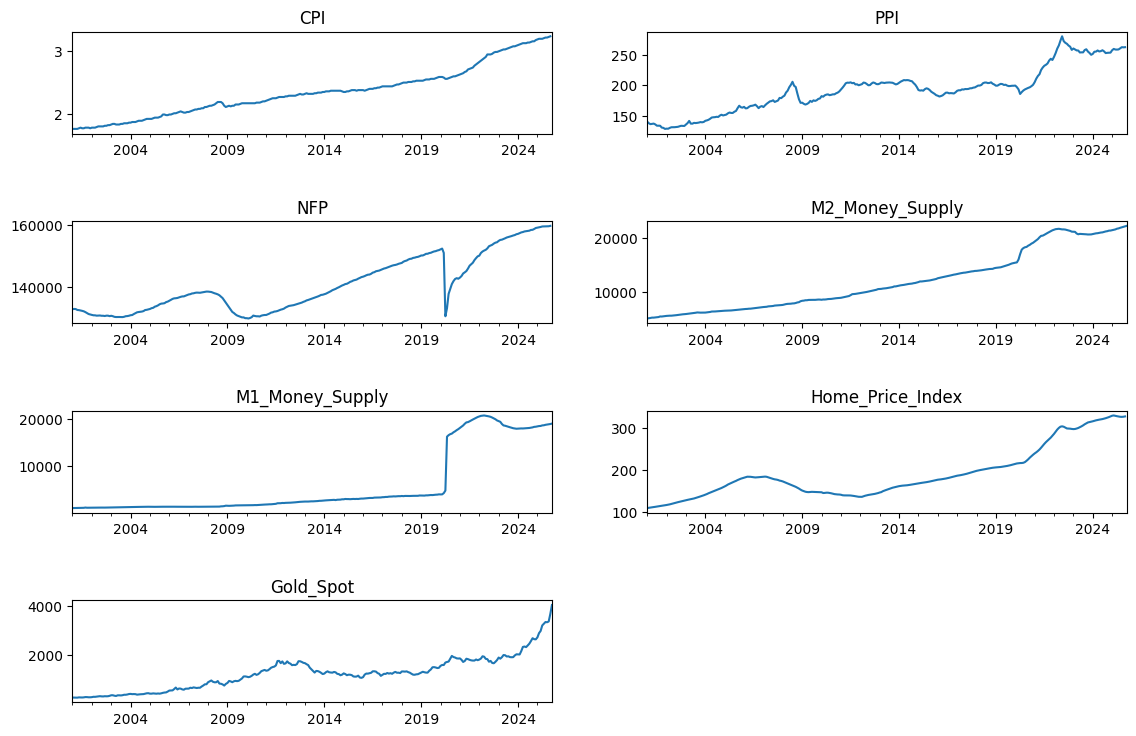

In [11]:

fig, axes = plt.subplots(4, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    df[col].plot(ax=axes[i], title=col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

if len(df.columns) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout(pad=3.0)
plt.show()


**Correlational Heatmap of features**

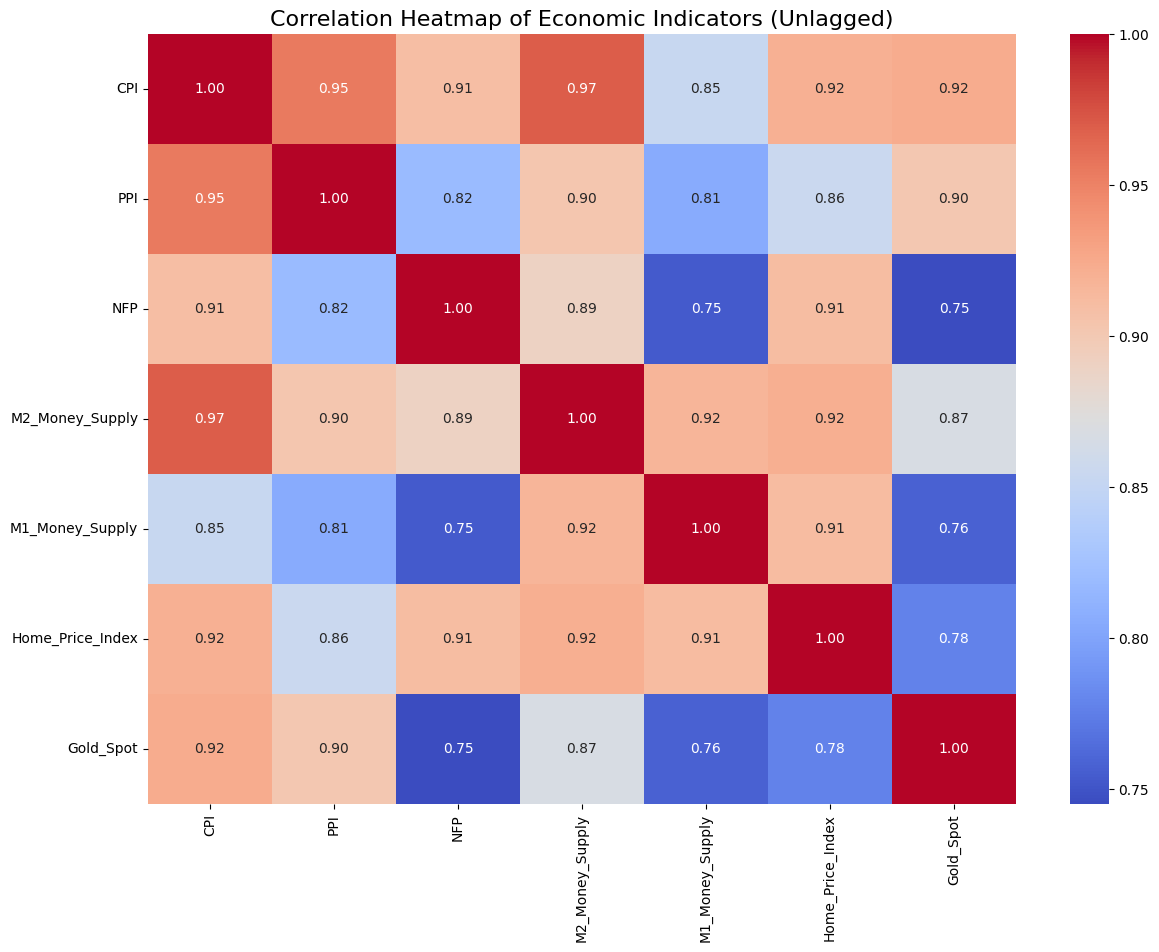

In [12]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Economic Indicators (Unlagged)", fontsize=16)
plt.show()

**Test Train Split**

In [13]:
X = df_model.drop(columns=[target])
Y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)


**Feature Scaling**

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Implementing Linear Regression + XGBoost (A hybrid Residual Learning Model)

**Train model**

In [15]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_train_pred = lr.predict(X_train_scaled)
lr_test_pred  = lr.predict(X_test_scaled)

**Compute residuals**

In [16]:
train_residuals = y_train - lr_train_pred

**Train XGBoost on residuals**

In [17]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror'
)

xgb.fit(X_train_scaled, train_residuals)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

**Predict Residuals**

In [18]:
xgb_train_resid_pred = xgb.predict(X_train_scaled)
xgb_test_resid_pred  = xgb.predict(X_test_scaled)

**Final Hybrid Prediction**

In [19]:
hybrid_train_pred = lr_train_pred + xgb_train_resid_pred
hybrid_test_pred  = lr_test_pred  + xgb_test_resid_pred

**Evaluation**

In [20]:
rmse = root_mean_squared_error(y_test, hybrid_test_pred)
mse = mean_squared_error(y_test, hybrid_test_pred)
mae  = mean_absolute_error(y_test, hybrid_test_pred)
r2 = r2_score(y_test, hybrid_test_pred)
mape = mean_absolute_percentage_error(y_test, hybrid_test_pred)

print("Hybrid LR + XGBoost Results:")
print(f"R-squared: {r2:.4f}")
print(f"MAE : {mae:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")


Hybrid LR + XGBoost Results:
R-squared: 0.9887
MAE : 0.0184
MAPE: 0.0061
MSE: 0.0004
RMSE: 0.0200


**Actual vs Predicted Plot**

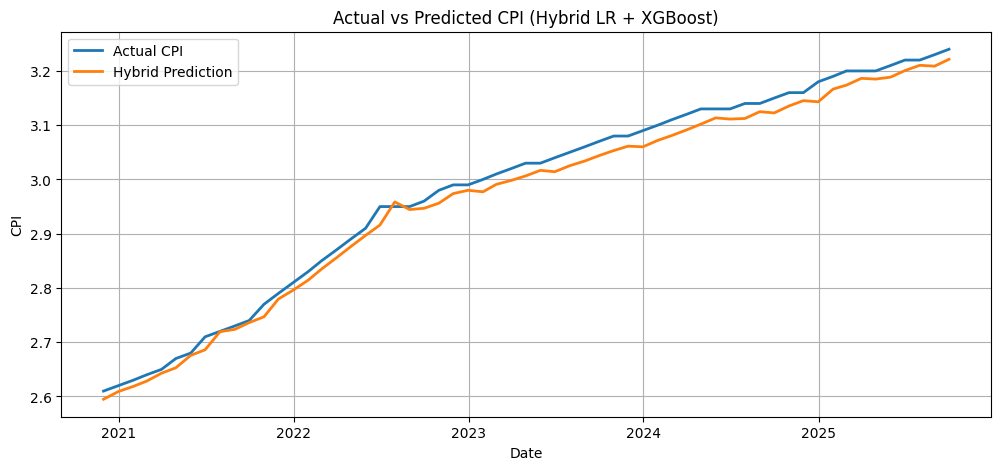

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test.values, label='Actual CPI', linewidth=2)
plt.plot(y_test.index, hybrid_test_pred, label='Hybrid Prediction', linewidth=2)
plt.title("Actual vs Predicted CPI (Hybrid LR + XGBoost)")
plt.xlabel("Date")
plt.ylabel("CPI")
plt.legend()
plt.grid(True)
plt.show()

# Comparing our models performance with FED's latest nowcast

**FED's last nowcast before actual release**

In [22]:
df_fed_nowcast = {
    "2024-01": 0.30, "2024-02": 0.13, "2024-03": 0.43,
    "2024-04": 0.34, "2024-05": 0.41, "2024-06": 0.08,
    "2024-07": 0.06, "2024-08": 0.23, "2024-09": 0.20,
    "2024-10": 0.10, "2024-11": 0.18, "2024-12": 0.26,
    "2025-01": 0.37, "2025-02": 0.24, "2025-03": 0.23,
    "2025-04": 0.02, "2025-05": 0.21, "2025-06": 0.12,
    "2025-07": 0.25, "2025-08": 0.16, "2025-09": 0.30
}


**Preparing last 21 month data**

In [23]:
X_last21_unscaled = df_model.drop(columns=["CPI"]).iloc[-21:]
X_last21_scaled = scaler.transform(X_last21_unscaled)


**Hybrid model prediction**

In [24]:
lr_pred = lr.predict(X_last21_scaled)
xgb_resid_pred = xgb.predict(X_last21_scaled)
model_pred_last21 = lr_pred + xgb_resid_pred

**GET ACTUAL CPI LAST 21 MONTHS + BASE CPI**

In [25]:
cpi_last22 = df_model["CPI"].iloc[-22:]

base_cpi = float(cpi_last22.iloc[0])

actual_cpi = cpi_last22.iloc[1:]



**MAP FED NOWCAST → CPI VALUES**

In [26]:
dates_last21 = list(actual_cpi.index)

def fed_key_formats(dt):
    return [
        f"1-{dt.month}-{str(dt.year)[-2:]}",  # 1-M-YY
        dt.strftime("%Y-%m"),                 # YYYY-MM
        f"{dt.month}-{str(dt.year)[-2:]}"     # M-YY
    ]

fed_pct_list = []
for dt in dates_last21:
    val = None
    for k in fed_key_formats(dt):
        if k in df_fed_nowcast:
            val = df_fed_nowcast[k]
            break
    fed_pct_list.append(np.nan if val is None else float(val))

# Convert % change → CPI
fed_cpi = []
prev = base_cpi
for pct in fed_pct_list:
    if np.isnan(pct):
        fed_cpi.append(np.nan)
    else:
        curr = prev * (1 + pct/100)
        fed_cpi.append(curr)
        prev = curr


**Error Comparison**

In [27]:
df_compare = pd.DataFrame({
    "Actual": actual_cpi,
    "Fed": fed_cpi,
    "Model": model_pred_last21
}, index=actual_cpi.index)

df_compare["Fed_Error_%"] = ((df_compare["Fed"] - df_compare["Actual"]) / df_compare["Actual"] * 100).round(2)
df_compare["Model_Error_%"] = ((df_compare["Model"] - df_compare["Actual"]) / df_compare["Actual"] * 100).round(2)

print(df_compare)


            Actual       Fed     Model  Fed_Error_%  Model_Error_%
Date                                                              
2024-01-31    3.10  3.099270  3.071978        -0.02          -0.90
2024-02-29    3.11  3.103299  3.080871        -0.22          -0.94
2024-03-31    3.12  3.116643  3.091261        -0.11          -0.92
2024-04-30    3.13  3.127240  3.101984        -0.09          -0.90
2024-05-31    3.13  3.140062  3.113476         0.32          -0.53
2024-06-30    3.13  3.142574  3.111280         0.40          -0.60
2024-07-31    3.14  3.144459  3.112358         0.14          -0.88
2024-08-31    3.14  3.151691  3.124897         0.37          -0.48
2024-09-30    3.15  3.157995  3.122580         0.25          -0.87
2024-10-31    3.16  3.161153  3.135433         0.04          -0.78
2024-11-30    3.16  3.166843  3.145210         0.22          -0.47
2024-12-31    3.18  3.175077  3.143093        -0.15          -1.16
2025-01-31    3.19  3.186824  3.166505        -0.10          -

**Plot actual vs Fed vs Our Model**

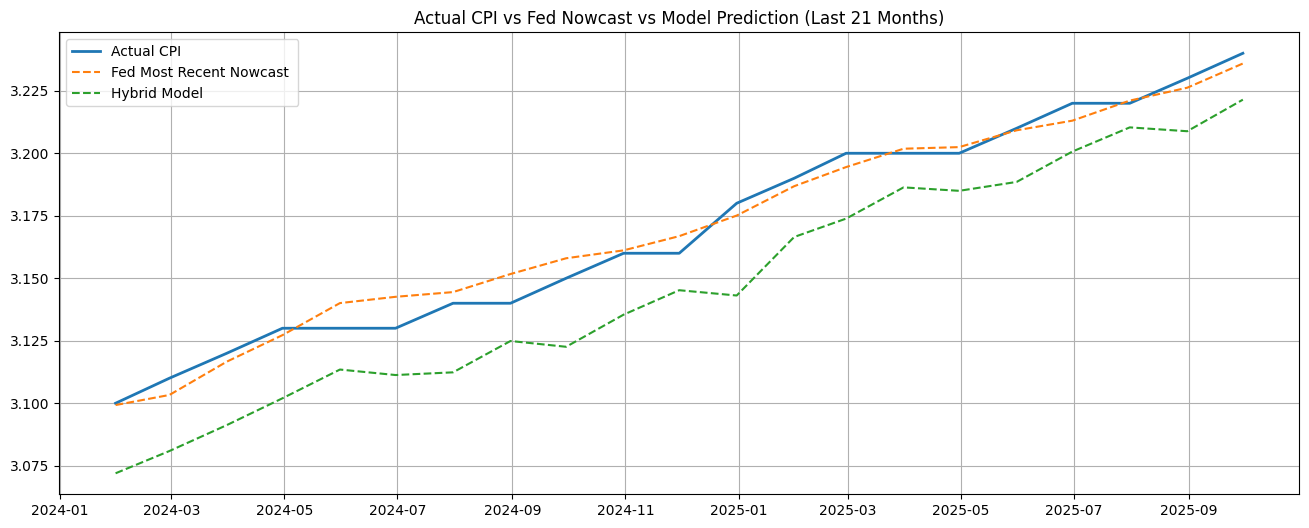

In [28]:

plt.figure(figsize=(16,6))
plt.plot(actual_cpi.index, actual_cpi.values, label="Actual CPI", linewidth=2)
plt.plot(actual_cpi.index, fed_cpi, label="Fed Most Recent Nowcast ", linestyle="--")
plt.plot(actual_cpi.index, model_pred_last21, label="Hybrid Model", linestyle="--")
plt.title("Actual CPI vs Fed Nowcast vs Model Prediction (Last 21 Months)")
plt.legend()
plt.grid(True)
plt.show()



**Bar Chart of Error%**

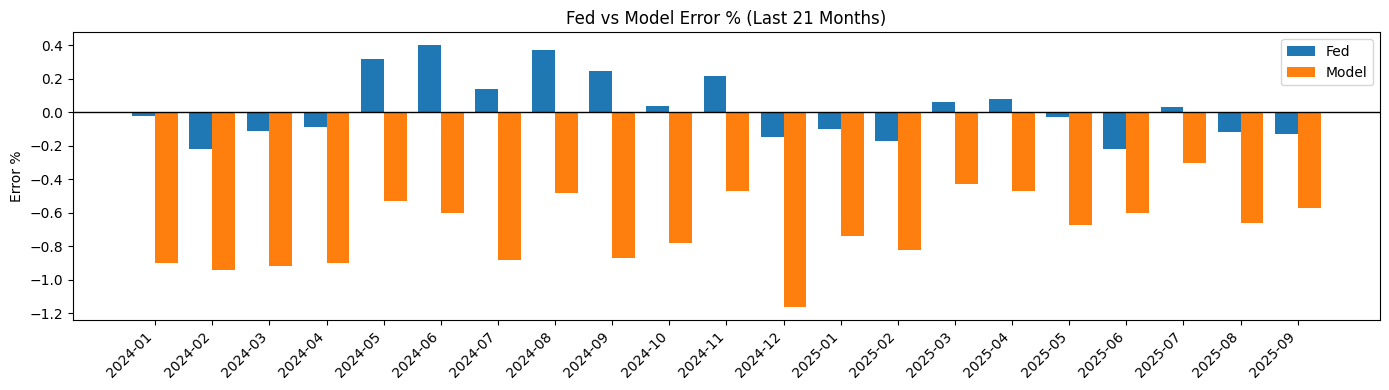

In [29]:
plt.figure(figsize=(14,4))
x = np.arange(len(df_compare))

plt.bar(x-0.2, df_compare["Fed_Error_%"], width=0.4, label="Fed")
plt.bar(x+0.2, df_compare["Model_Error_%"], width=0.4, label="Model")

plt.xticks(x, [d.strftime("%Y-%m") for d in df_compare.index], rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=1)
plt.ylabel("Error %")
plt.title("Fed vs Model Error % (Last 21 Months)")
plt.legend()
plt.tight_layout()
plt.show()
